# 가입 이후 유저의 행동 확인

In [23]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.cloud import bigquery

In [41]:
sns.set_theme(style="darkgrid")

plt.rc('font', family='AppleGothic')
# 마이너스 폰트 깨짐 방지 설정
plt.rcParams['axes.unicode_minus'] = False

In [5]:
PROJECT_ID = "sns-analysis-prj"
DATA_SET = "sns_analysis"

client = bigquery.Client(project=PROJECT_ID)

* event table 정보

  * 데이터 규모 : 11441319행
  * 집계 기간 : 2023-07-18 00:00:00 ~ 2023-08-10 23:59:59

* event - property JOIN 테이블 정보
  * 유저 수 : 230740명

* event - property JOIN 테이블 (이벤트 집계 기간 내 회원가입이 발생한 유저 대상)
  * 유저 수 : 940명

## 기한 내 가입이 이루어진 유저의 이벤트 테이블 호출

In [6]:
sql = f"""
    SELECT * FROM `{PROJECT_ID}.{DATA_SET}.mart_after_signup_event`
"""

# 판다스 데이터프레임으로 변환
df = client.query(sql).to_dataframe()

print(df.head())

   user_id            event_datetime       event_key item_name page_name  \
0  1578957 2023-07-18 00:01:34+00:00  $session_start                       
1  1578957 2023-07-18 00:01:34+00:00      launch_app                       
2  1578957 2023-07-18 00:01:34+00:00      launch_app                       
3  1578957 2023-07-18 00:01:34+00:00  $session_start                       
4  1578957 2023-07-18 00:01:47+00:00     view_signup                학년선택   

   friend_count  votes_count  heart_balance  question_id  
0           NaN          NaN            NaN          NaN  
1           NaN          NaN            NaN          NaN  
2           NaN          NaN            NaN          NaN  
3           NaN          NaN            NaN          NaN  
4           NaN          NaN            NaN          NaN  


In [7]:
df['user_id'].nunique()  # 유저 수 확인

940

In [8]:
df[df['event_key'] == 'complete_signup']  # 가입 완료 이벤트 확인

,user_id,event_datetime,event_key,item_name,page_name,friend_count,votes_count,heart_balance,question_id
18,1578957,2023-07-18 00:02:35+00:00,complete_signup,,,0.0,0.0,300.0,NaN
19,1578957,2023-07-18 00:02:35+00:00,complete_signup,,,0.0,0.0,300.0,NaN
227,1578958,2023-07-18 00:03:36+00:00,complete_signup,,,0.0,0.0,300.0,NaN
305,1578959,2023-07-18 00:09:23+00:00,complete_signup,,,0.0,0.0,300.0,NaN
306,1578959,2023-07-18 00:09:23+00:00,complete_signup,,,0.0,0.0,300.0,NaN
...,...,...,...,...,...,...,...,...,...
320839,1579928,2023-08-10 21:31:08+00:00,complete_signup,,,0.0,0.0,300.0,NaN
320885,1579929,2023-08-10 21:45:31+00:00,complete_signup,,,0.0,0.0,300.0,NaN
320962,1579930,2023-08-10 21:49:58+00:00,complete_signup,,,0.0,0.0,300.0,NaN
320991,1579931,2023-08-10 21:55:10+00:00,complete_signup,,,0.0,0.0,300.0,NaN


In [9]:
df[df['event_key'] == 'complete_signup'].duplicated().sum()  # 가입 완료 이벤트 확인

np.int64(221)

#### ⚠️ 회원가입 이벤트 중복 확인

- **940명의 사용자가 총 1,161건의 회원가입 이벤트를 발생시킨 현상**을 확인했습니다.
- 확인 결과, `event` 데이터 전처리 과정에서 **중복 이벤트에 대한 처리가 누락된 것**으로 판단됩니다.
- 중복 이벤트가 포함될 경우 회원가입 이벤트 수가 실제보다 과대 집계될 수 있으므로, **중복 데이터를 제거한 후 이후 분석을 진행합니다.**

In [10]:
df.shape

(321031, 9)

In [11]:
df.duplicated().sum()  # 전체 중복 확인 

np.int64(114102)

In [12]:
df[df.duplicated(keep=False)]

,user_id,event_datetime,event_key,item_name,page_name,friend_count,votes_count,heart_balance,question_id
0,1578957,2023-07-18 00:01:34+00:00,$session_start,,,NaN,NaN,NaN,NaN
1,1578957,2023-07-18 00:01:34+00:00,launch_app,,,NaN,NaN,NaN,NaN
2,1578957,2023-07-18 00:01:34+00:00,launch_app,,,NaN,NaN,NaN,NaN
3,1578957,2023-07-18 00:01:34+00:00,$session_start,,,NaN,NaN,NaN,NaN
4,1578957,2023-07-18 00:01:47+00:00,view_signup,,학년선택,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
320905,1579929,2023-08-10 21:51:52+00:00,click_random_ask_shuffle,,,0.0,0.0,574.0,NaN
320906,1579929,2023-08-10 21:51:53+00:00,click_random_ask_shuffle,,,0.0,0.0,574.0,NaN
320907,1579929,2023-08-10 21:51:53+00:00,click_random_ask_shuffle,,,0.0,0.0,574.0,NaN
320931,1579929,2023-08-10 23:04:49+00:00,click_bottom_navigation_profile,,,0.0,0.0,300.0,NaN


In [13]:
df = df.drop_duplicates(keep='first')  # 중복 제거

In [14]:
df.shape

(206929, 9)

In [15]:
df[df['event_key'] == 'complete_signup']  # 가입 완료 이벤트 확인

,user_id,event_datetime,event_key,item_name,page_name,friend_count,votes_count,heart_balance,question_id
18,1578957,2023-07-18 00:02:35+00:00,complete_signup,,,0.0,0.0,300.0,NaN
227,1578958,2023-07-18 00:03:36+00:00,complete_signup,,,0.0,0.0,300.0,NaN
305,1578959,2023-07-18 00:09:23+00:00,complete_signup,,,0.0,0.0,300.0,NaN
416,1578960,2023-07-18 00:10:26+00:00,complete_signup,,,0.0,0.0,300.0,NaN
2838,1578961,2023-07-18 00:11:14+00:00,complete_signup,,,0.0,0.0,300.0,NaN
...,...,...,...,...,...,...,...,...,...
320839,1579928,2023-08-10 21:31:08+00:00,complete_signup,,,0.0,0.0,300.0,NaN
320885,1579929,2023-08-10 21:45:31+00:00,complete_signup,,,0.0,0.0,300.0,NaN
320962,1579930,2023-08-10 21:49:58+00:00,complete_signup,,,0.0,0.0,300.0,NaN
320991,1579931,2023-08-10 21:55:10+00:00,complete_signup,,,0.0,0.0,300.0,NaN


# 발생한 이벤트 종류

In [16]:
df['event_key'].value_counts()  # 이벤트별 발생 횟수 확인

event_key
view_lab_tap                         21215
view_timeline_tap                    20332
click_question_open                  19369
launch_app                           14587
$session_start                       13301
skip_question                        13057
click_bottom_navigation_questions    12154
$session_end                         11822
click_bottom_navigation_profile      11264
click_bottom_navigation_timeline      7922
view_signup                           7373
click_question_start                  7340
view_profile_tap                      6090
view_questions_tap                    6082
complete_question                     5634
click_bottom_navigation_lab           5314
click_notice_detail                   4368
click_appbar_chat_rooms               3885
click_appbar_alarm_center             3487
click_question_share                  2133
click_question_ask                    1873
click_attendance                      1809
click_appbar_friend_plus              1279
c

In [17]:
df[
    (df['event_key'] == 'button') |
    (df['event_key'] == 'click_appbar_setting')
]['event_key'].value_counts()

event_key
click_appbar_setting    717
button                    1
Name: count, dtype: int64

In [18]:
df[df['event_key'] == 'click_appbar_setting'][['item_name', 'page_name']].value_counts()

item_name  page_name
                        717
Name: count, dtype: int64

컬럼 명세서와 기획서에서 정의를 확인할 수 없는 이벤트로 `button`, `click_appbar_setting`이 존재합니다.
- `button`: 이벤트명만으로 구체적인 대상과 행동을 식별하기 어렵습니다.
- `click_appbar_setting`: 명칭상 앱 상단의 설정 버튼 클릭으로 추정되지만, 실제 발생 조건과 화면 이동 여부는 확인되지 않았습니다.

행동 의미의 해석이 필요한 가입 후 경로·퍼널 분석에서는 제외합니다.

In [19]:
excluded_events = ['button', 'click_appbar_setting']

analysis_df = df[
    ~df['event_key'].isin(excluded_events)
].copy()

In [20]:
analysis_df

,user_id,event_datetime,event_key,item_name,page_name,friend_count,votes_count,heart_balance,question_id
0,1578957,2023-07-18 00:01:34+00:00,$session_start,,,NaN,NaN,NaN,NaN
1,1578957,2023-07-18 00:01:34+00:00,launch_app,,,NaN,NaN,NaN,NaN
4,1578957,2023-07-18 00:01:47+00:00,view_signup,,학년선택,NaN,NaN,NaN,NaN
6,1578957,2023-07-18 00:01:50+00:00,view_signup,,반선택,NaN,NaN,NaN,NaN
8,1578957,2023-07-18 00:02:01+00:00,view_signup,,번호인증,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
321026,1579932,2023-08-10 23:43:42+00:00,view_profile_tap,,,0.0,0.0,300.0,NaN
321027,1579932,2023-08-10 23:43:42+00:00,click_bottom_navigation_profile,,,0.0,0.0,300.0,NaN
321028,1579932,2023-08-10 23:43:51+00:00,click_appbar_friend_plus,,,0.0,0.0,300.0,NaN
321029,1579932,2023-08-10 23:44:43+00:00,click_bottom_navigation_profile,,,0.0,0.0,300.0,NaN


In [22]:
analysis_df['question_id'].unique()

array([  nan, 1095., 4567., ..., 4653.,  445.,  262.], shape=(3599,))

# 가입 직후 행동 확인

In [39]:
# 정의가 불명확한 이벤트를 제외한 분석용 로그
events = analysis_df.dropna(subset=['user_id', 'event_datetime']).copy()

events = events.sort_values(
    ['user_id', 'event_datetime'],
    kind='stable',
)

events['다음 행동'] = (
    events.groupby('user_id')['event_key'].shift(-1)
)
events['다음 행동 시각'] = (
    events.groupby('user_id')['event_datetime'].shift(-1)
)

# 유저별 최초 complete_signup 이후 행동
signup_next = (
    events.loc[events['event_key'].eq('complete_signup')]
    .drop_duplicates('user_id', keep='first')
    .copy()
)

signup_next['다음 행동'] = signup_next['다음 행동'].fillna(
    '후속 이벤트 미관측'
)

next_action_summary = (
    signup_next['다음 행동']
    .value_counts()
    .rename_axis('가입 후 첫 행동')
    .reset_index(name='유저 수')
)

next_action_summary['비중(%)'] = (
    (next_action_summary['유저 수'] / len(signup_next) * 100).round(2)
    if len(signup_next) else float('nan')
)

display(next_action_summary)

,가입 후 첫 행동,유저 수,비중(%)
0,$session_start,414,44.04
1,view_timeline_tap,117,12.45
2,click_question_start,76,8.09
3,view_lab_tap,61,6.49
4,click_bottom_navigation_timeline,57,6.06
5,click_bottom_navigation_questions,44,4.68
6,launch_app,25,2.66
7,click_bottom_navigation_profile,25,2.66
8,후속 이벤트 미관측,24,2.55
9,$session_end,16,1.70


In [28]:
RETENTION_DAYS = [1, 3, 7, 14]

ACTIVE_EVENTS = [
    # 'view_timeline_tap',
    # 'view_lab_tap',
    # 'view_profile_tap',
    # 'view_questions_tap',
    # 'click_question_open',
    # 'click_question_start',
    # 'complete_question',
    # 'skip_question',
    # 'click_attendance',
    # 'view_shop',
    '$session_start'
]

# 노트북에 기록된 관측 기간 기준
# 실제 데이터의 마지막 이벤트 시각이 아닌, 수집 종료 경계를 사용
OBSERVATION_END = pd.Timestamp('2023-08-11 00:00:00', tz='UTC')

# 유저별 최초 가입 완료 시각
signup_users = (
    analysis_df.loc[
        analysis_df['event_key'].eq('complete_signup'),
        ['user_id', 'event_datetime'],
    ]
    .dropna()
    .groupby('user_id', as_index=False)['event_datetime']
    .min()
    .rename(columns={'event_datetime': 'signup_at'})
)

# 기존 시간대를 유지한 채 날짜 구분
signup_users['signup_day'] = signup_users['signup_at'].dt.floor('D')

# 활동 이벤트에 가입 시각 연결
activity = (
    analysis_df.loc[
        analysis_df['event_key'].isin(ACTIVE_EVENTS),
        ['user_id', 'event_datetime'],
    ]
    .dropna()
    .merge(signup_users, on='user_id', how='inner', validate='many_to_one')
)

# 가입 이후이며 관측 기간 안에 있는 활동만 사용
activity = activity.loc[
    activity['event_datetime'].ge(activity['signup_at'])
    & activity['event_datetime'].lt(OBSERVATION_END)
].copy()

activity['activity_day'] = activity['event_datetime'].dt.floor('D')

# 같은 날 여러 번 활동해도 유저당 한 번으로 계산
activity_days = activity[
    ['user_id', 'activity_day']
].drop_duplicates()

In [29]:
records = []

for day in RETENTION_DAYS:
    eligible = signup_users[['user_id', 'signup_day']].copy()

    eligible['target_day'] = (
        eligible['signup_day'] + pd.Timedelta(days=day)
    )

    # 목표 날짜의 종료 시각까지 데이터가 있어야 분석 대상
    eligible = eligible.loc[
        eligible['target_day'] + pd.Timedelta(days=1)
        <= OBSERVATION_END
    ]

    matched = eligible.merge(
        activity_days,
        left_on=['user_id', 'target_day'],
        right_on=['user_id', 'activity_day'],
        how='left',
        validate='one_to_one',
        indicator=True,
    )

    eligible_count = len(eligible)
    retained_count = matched['_merge'].eq('both').sum()

    records.append({
        '경과일': f'D{day}',
        '관찰 가능한 가입자 수': eligible_count,
        '해당일 활동 유저 수': retained_count,
        '리텐션(%)': (
            retained_count / eligible_count * 100
            if eligible_count else float('nan')
        ),
    })

retention_summary = pd.DataFrame(records)
retention_summary['리텐션(%)'] = (
    retention_summary['리텐션(%)'].round(2)
)

display(retention_summary)

,경과일,관찰 가능한 가입자 수,해당일 활동 유저 수,리텐션(%)
0,D1,910,375,41.21
1,D3,847,246,29.04
2,D7,717,190,26.50
3,D14,550,105,19.09


In [32]:
sql2 = f"""
    SELECT * FROM `{PROJECT_ID}.{DATA_SET}.mart_after_signup_event` AS e
    INNER JOIN `{PROJECT_ID}.{DATA_SET}.accounts_user` AS u
    ON e.user_id = CAST(u.id AS STRING)
    INNER JOIN `{PROJECT_ID}.{DATA_SET}.accounts_group` AS g
    ON u.group_id = g.id
    INNER JOIN `{PROJECT_ID}.{DATA_SET}.accounts_school` AS s
    ON g.school_id = s.id
"""

# 판다스 데이터프레임으로 변환
df2 = client.query(sql2).to_dataframe()

print(df2.head())

   user_id            event_datetime       event_key item_name page_name  \
0  1579151 2023-07-20 19:41:10+00:00  $session_start                       
1  1579151 2023-07-20 19:41:10+00:00  $session_start                       
2  1579151 2023-07-20 19:41:10+00:00      launch_app                       
3  1579151 2023-07-20 19:41:10+00:00      launch_app                       
4  1579151 2023-07-20 19:41:17+00:00     view_signup                학년선택   

   friend_count  votes_count  heart_balance  question_id       id  ...  \
0           NaN          NaN            NaN          NaN  1579151  ...   
1           NaN          NaN            NaN          NaN  1579151  ...   
2           NaN          NaN            NaN          NaN  1579151  ...   
3           NaN          NaN            NaN          NaN  1579151  ...   
4           NaN          NaN            NaN          NaN  1579151  ...   

   pending_votes  group_id   id_1  grade class_num  school_id  id_2  address  \
0              0  

In [33]:
user_region = df2[['user_id', 'address']].drop_duplicates().copy()

if user_region['user_id'].duplicated().any():
    raise ValueError('동일 유저에 여러 주소가 연결되어 있습니다.')

address = (
    user_region['address']
    .astype('string')
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .replace({'-': pd.NA, '': pd.NA})
)

parts = address.str.split(n=2, expand=True).reindex(columns=[0, 1])

user_region['시도'] = parts[0].fillna('미상')
user_region['시군구'] = parts[1].fillna('미기재')

# 기존 전체 리텐션의 가입자 분모를 유지
regional_signups = signup_users.merge(
    user_region[['user_id', '시도', '시군구']],
    on='user_id',
    how='left',
    validate='one_to_one',
)

regional_signups[['시도', '시군구']] = (
    regional_signups[['시도', '시군구']].fillna('미상')
)

In [34]:
def regional_retention(signups, activity_days, region_cols):
    results = []

    for day in RETENTION_DAYS:
        eligible = signups.copy()
        eligible['target_day'] = (
            eligible['signup_day'] + pd.Timedelta(days=day)
        )

        eligible = eligible.loc[
            eligible['target_day'] + pd.Timedelta(days=1)
            <= OBSERVATION_END
        ]

        matched = eligible.merge(
            activity_days[['user_id', 'activity_day']].drop_duplicates(),
            left_on=['user_id', 'target_day'],
            right_on=['user_id', 'activity_day'],
            how='left',
            validate='one_to_one',
            indicator=True,
        )

        matched['retained'] = matched['_merge'].eq('both')

        summary = (
            matched.groupby(region_cols)
            .agg(
                관찰가능가입자수=('user_id', 'nunique'),
                세션시작유저수=('retained', 'sum'),
            )
            .reset_index()
        )

        summary['경과일'] = f'D{day}'
        summary['리텐션(%)'] = (
            summary['세션시작유저수']
            / summary['관찰가능가입자수'] * 100
        ).round(2)

        results.append(summary)

    return pd.concat(results, ignore_index=True)

In [35]:
region_retention = regional_retention(
    regional_signups,
    activity_days,
    region_cols=['시도'],
)

display(region_retention)

display(
    region_retention.pivot(
        index='시도',
        columns='경과일',
        values='리텐션(%)',
    ).reindex(columns=[f'D{day}' for day in RETENTION_DAYS])
)

,시도,관찰가능가입자수,세션시작유저수,경과일,리텐션(%)
0,강원도,17,4,D1,23.53
1,경기도,193,83,D1,43.01
2,경상남도,51,18,D1,35.29
3,경상북도,75,39,D1,52.00
4,광주광역시,17,6,D1,35.29
...,...,...,...,...,...
63,전라남도,18,3,D14,16.67
64,전라북도,20,4,D14,20.00
65,제주특별자치도,5,0,D14,0.00
66,충청남도,36,10,D14,27.78


경과일,D1,D3,D7,D14
시도,,,,
강원도,23.53,20.00,9.09,22.22
경기도,43.01,32.40,27.92,23.20
경상남도,35.29,34.15,28.12,29.63
경상북도,52.00,47.14,45.16,32.08
광주광역시,35.29,25.00,45.45,37.50
대구광역시,37.93,14.81,4.35,5.00
대전광역시,70.00,50.00,50.00,0.00
미상,17.05,7.69,5.10,3.08
부산광역시,37.50,15.62,11.11,4.76


In [37]:
city_retention = regional_retention(
    regional_signups,
    activity_days,
    region_cols=['시도', '시군구'],
)

display(city_retention)

display(
    city_retention.pivot(
        index=['시도', '시군구'],
        columns='경과일',
        values='리텐션(%)',
    ).reindex(columns=[f'D{day}' for day in RETENTION_DAYS])
)

,시도,시군구,관찰가능가입자수,세션시작유저수,경과일,리텐션(%)
0,강원도,강릉시,3,1,D1,33.33
1,강원도,고성군,1,1,D1,100.00
2,강원도,동해시,2,1,D1,50.00
3,강원도,속초시,2,0,D1,0.00
4,강원도,원주시,5,1,D1,20.00
...,...,...,...,...,...,...
621,충청북도,영동군,9,1,D14,11.11
622,충청북도,음성군,4,1,D14,25.00
623,충청북도,제천시,3,0,D14,0.00
624,충청북도,청주시,16,5,D14,31.25


경과일           D1     D3     D7    D14
시도   시군구                             
강원도  강릉시   33.33   0.00   0.00   0.00
     고성군  100.00    NaN    NaN    NaN
     동해시   50.00  50.00   0.00   0.00
     속초시    0.00  50.00   0.00   0.00
     원주시   20.00  20.00  33.33  33.33
...          ...    ...    ...    ...
충청북도 음성군   50.00   0.00   0.00  25.00
     제천시   25.00  25.00  50.00   0.00
     진천군    0.00   0.00   0.00    NaN
     청주시   63.64  59.09  60.00  31.25
     충주시   66.67  66.67  66.67  66.67

[169 rows x 4 columns]

In [38]:
def plot_regional_retention(data, region_cols, title):
    if data.empty:
        print('표시할 데이터가 없습니다.')
        return

    plot_data = data.copy()
    plot_data['지역'] = (
        plot_data[region_cols].astype(str).agg(' '.join, axis=1)
    )

    day_order = [f'D{day}' for day in RETENTION_DAYS]

    # D1 관찰 가능 가입자가 많은 지역부터 표시
    region_order = (
        plot_data.loc[plot_data['경과일'].eq(day_order[0])]
        .sort_values('관찰가능가입자수', ascending=False)['지역']
        .tolist()
    )
    region_order += [
        region for region in plot_data['지역'].unique()
        if region not in region_order
    ]

    rates = (
        plot_data.pivot(
            index='지역', columns='경과일', values='리텐션(%)'
        )
        .reindex(index=region_order, columns=day_order)
    )

    plot_data['라벨'] = plot_data.apply(
        lambda row: (
            f"{row['리텐션(%)']:.1f}%\n"
            f"({int(row['세션시작유저수'])}/"
            f"{int(row['관찰가능가입자수'])})"
        ),
        axis=1,
    )

    annotations = (
        plot_data.pivot(
            index='지역', columns='경과일', values='라벨'
        )
        .reindex(index=region_order, columns=day_order)
        .fillna('')
    )

    fig, ax = plt.subplots(
        figsize=(10, max(3, len(rates) * 0.65 + 1.5))
    )

    # 관찰 대상이 없는 칸은 회색
    ax.set_facecolor('#eeeeee')

    sns.heatmap(
        rates,
        annot=annotations,
        fmt='',
        mask=rates.isna(),
        cmap='Blues',
        vmin=0,
        vmax=100,
        linewidths=0.5,
        cbar_kws={'label': '리텐션(%)'},
        ax=ax,
    )

    ax.set_title(
        f'{title}\n비율 아래 괄호: 세션 시작 유저 / 관찰 가능 가입자',
        pad=15,
    )
    ax.set_xlabel('가입 후 경과일')
    ax.set_ylabel('')
    ax.tick_params(axis='y', labelrotation=0)

    fig.tight_layout()
    plt.show()
    plt.close(fig)

In [44]:
region_retention[region_retention['시도']=='미상']

,시도,관찰가능가입자수,세션시작유저수,경과일,리텐션(%)
7,미상,129,22,D1,17.05
24,미상,117,9,D3,7.69
41,미상,98,5,D7,5.10
58,미상,65,2,D14,3.08


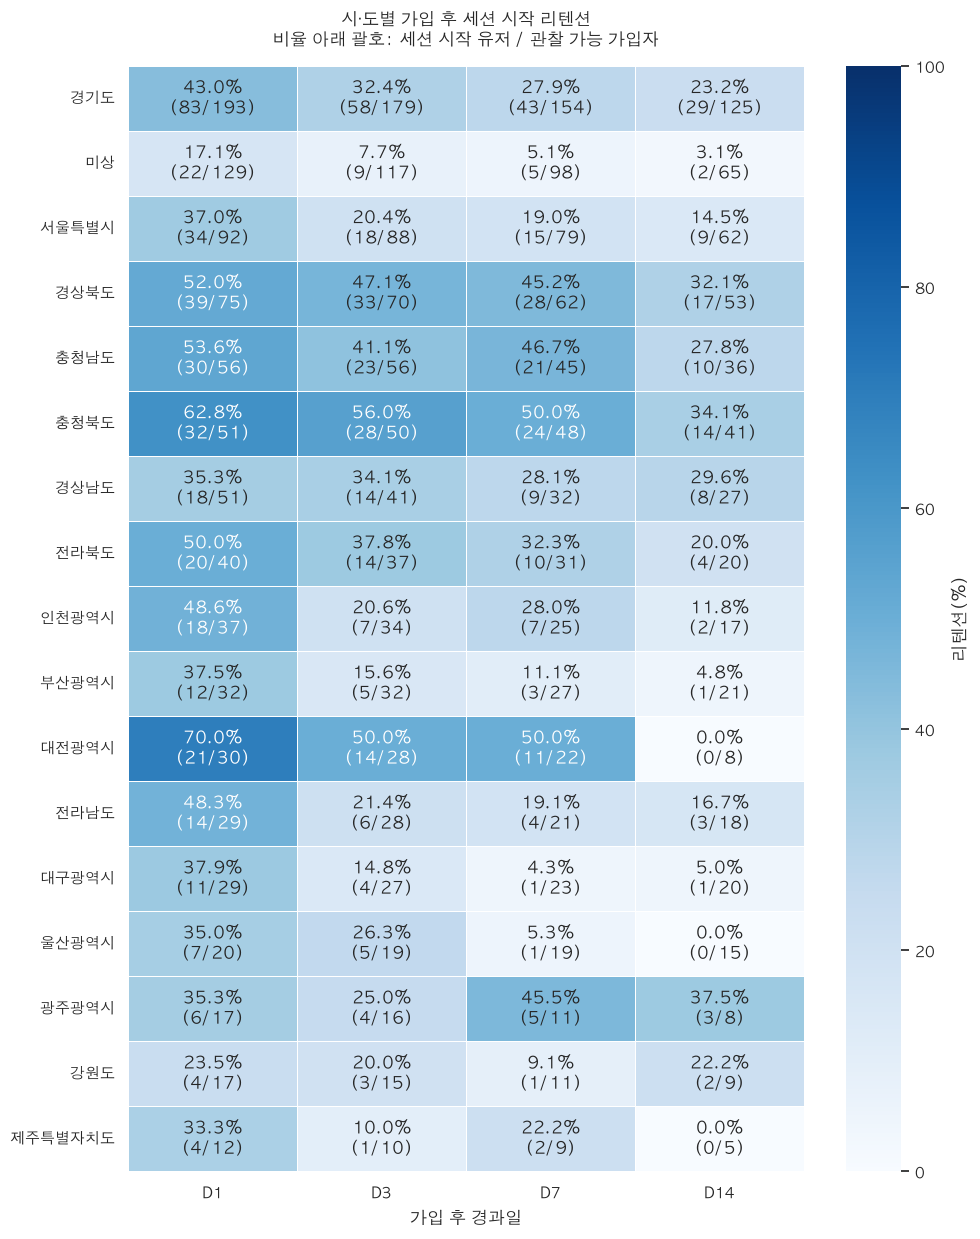

In [42]:
plot_regional_retention(
    region_retention,
    region_cols=['시도'],
    title='시·도별 가입 후 세션 시작 리텐션',
)

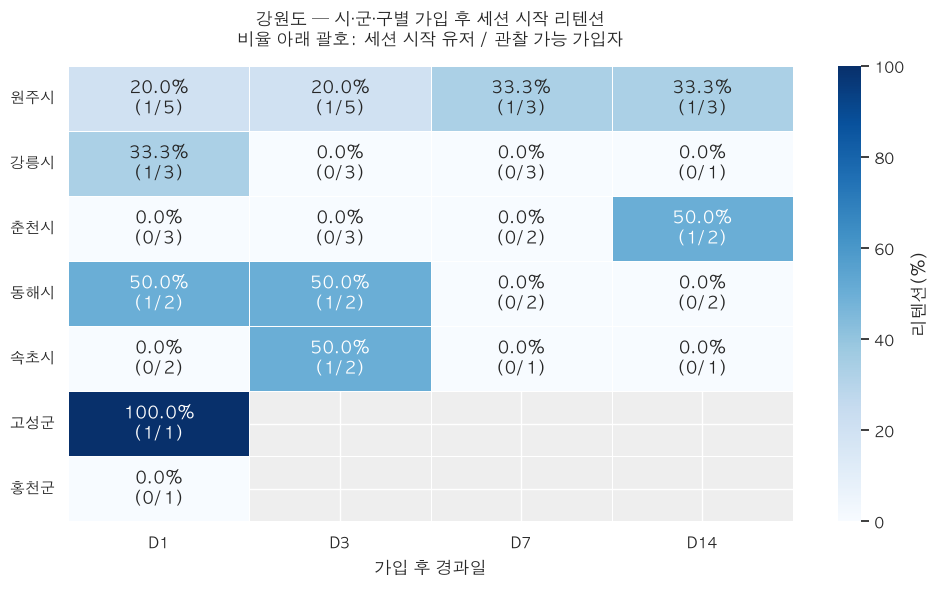

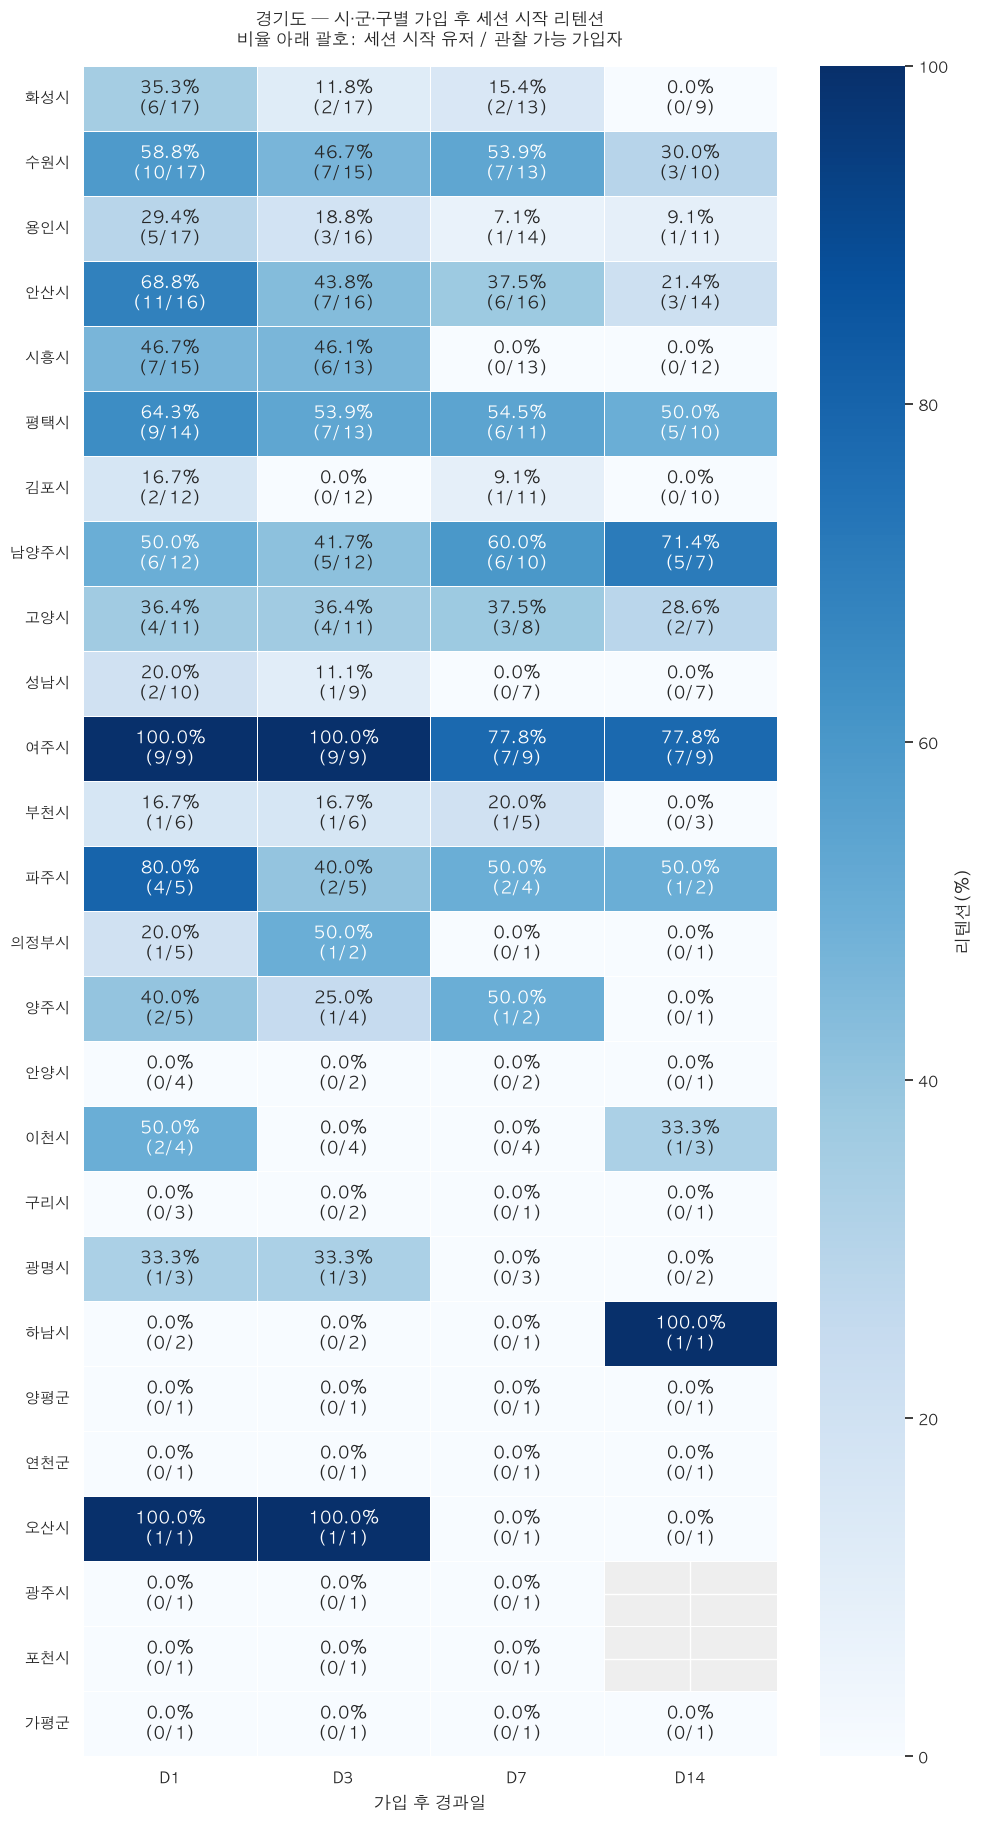

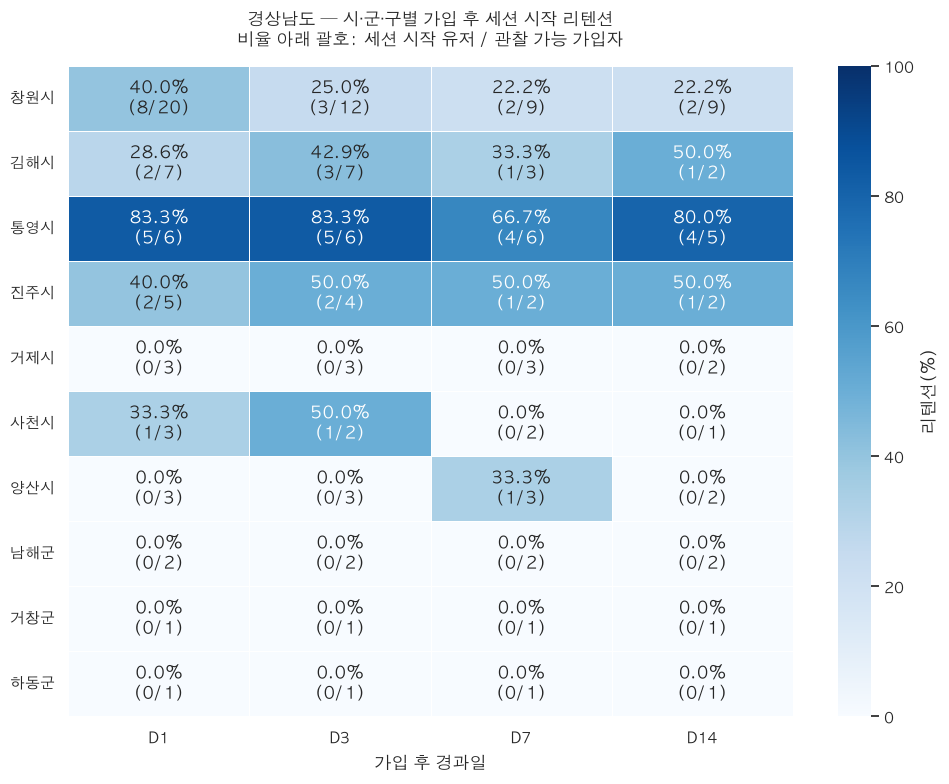

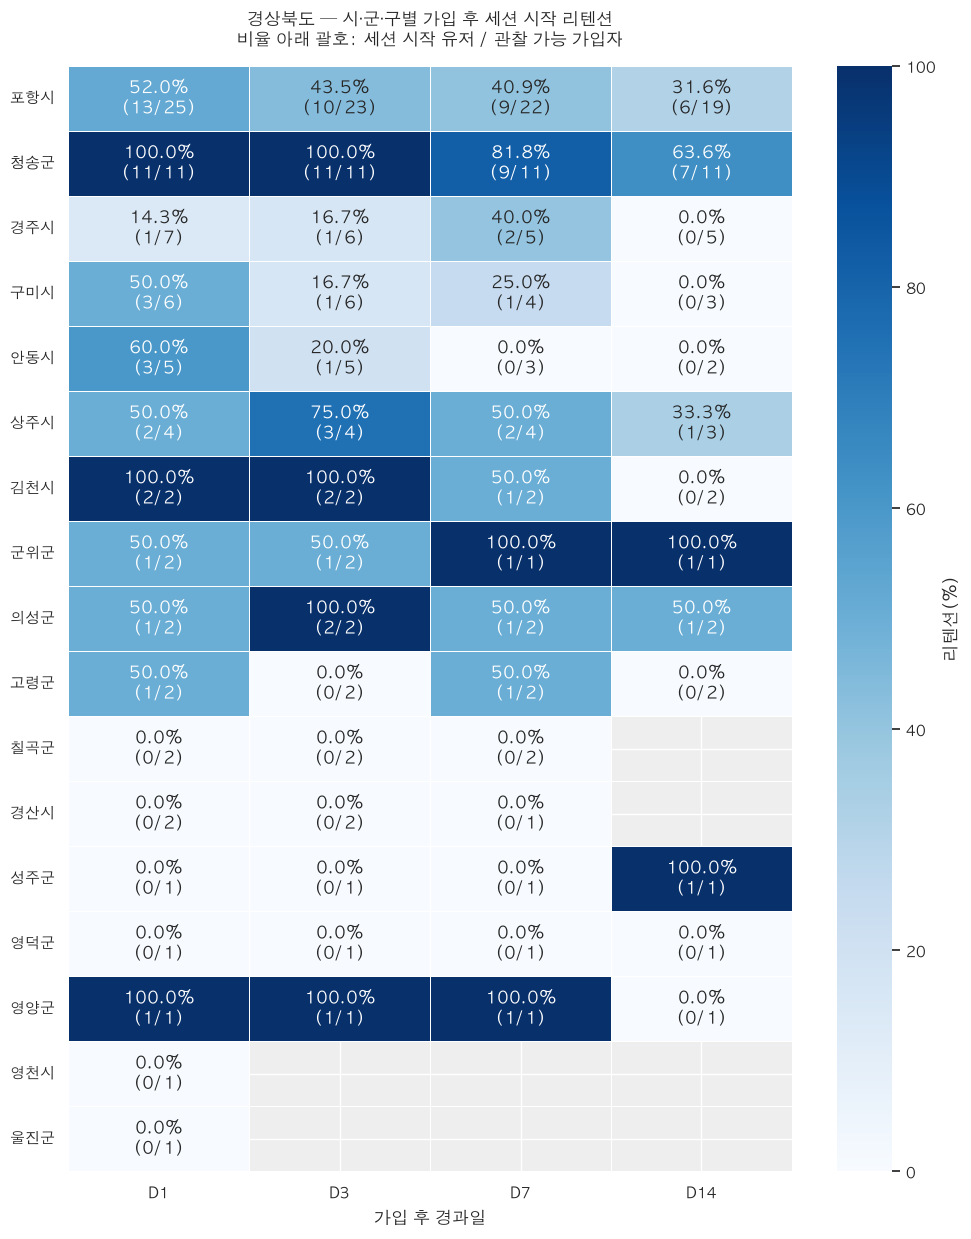

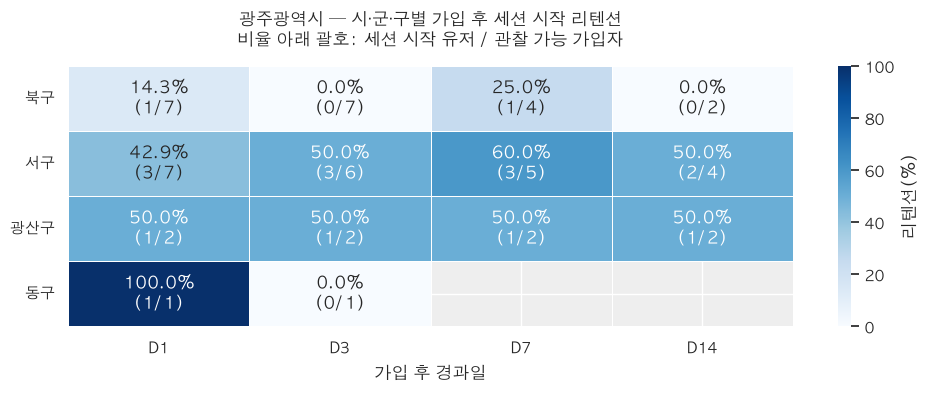

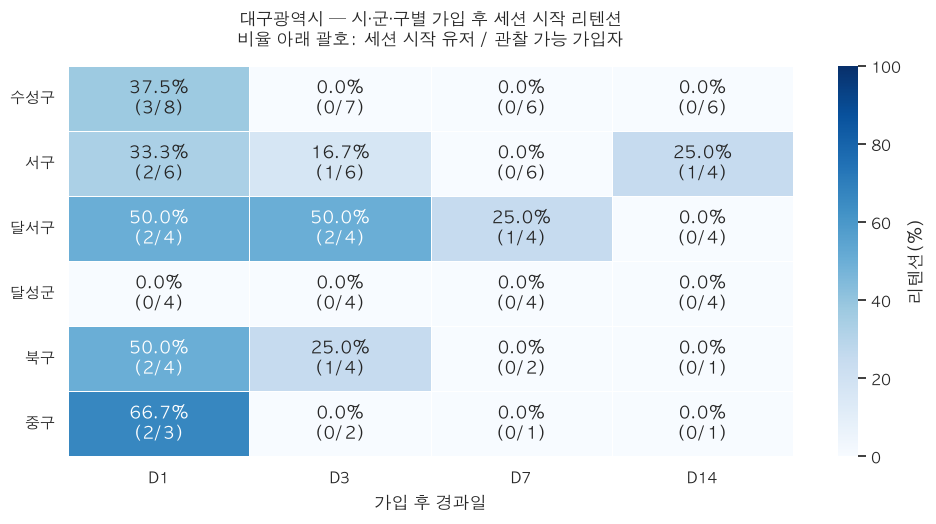

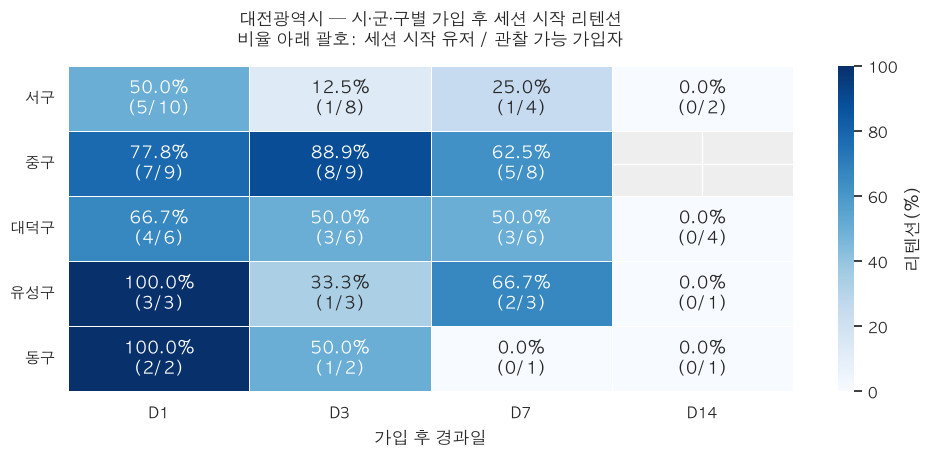

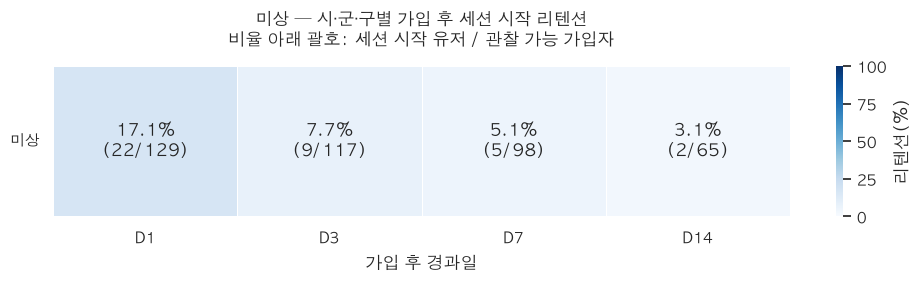

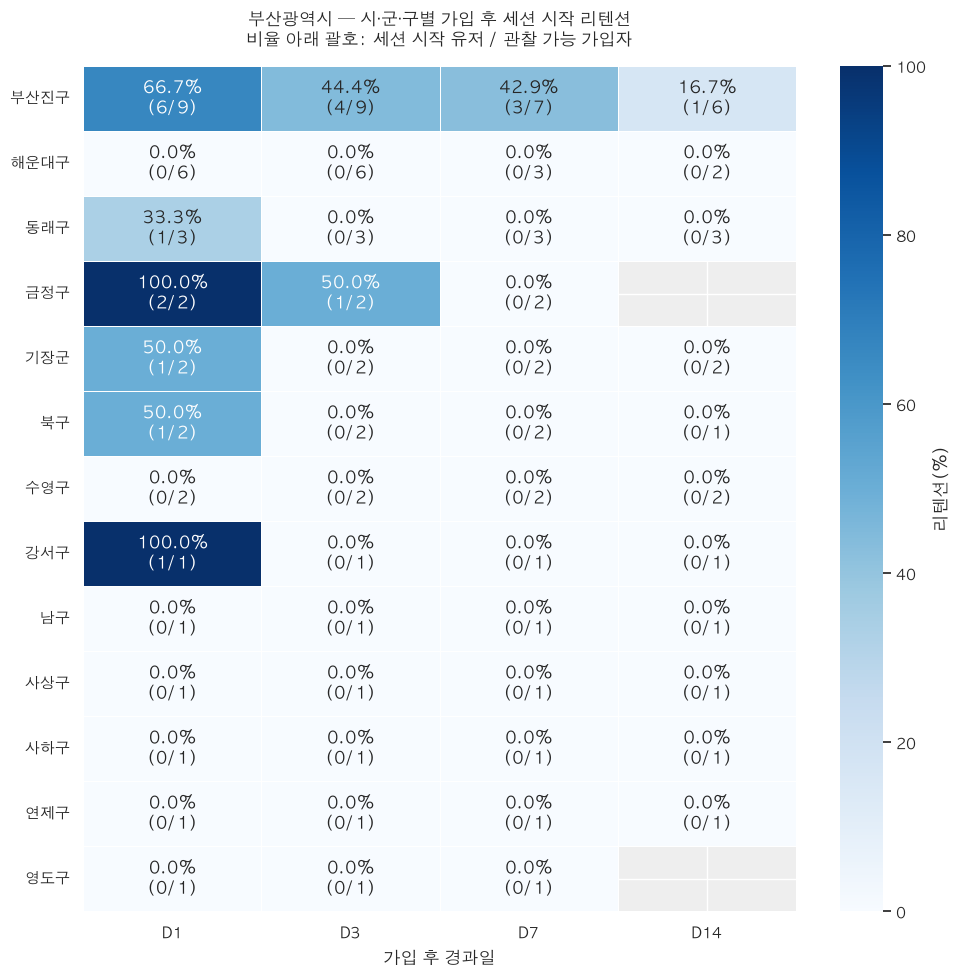

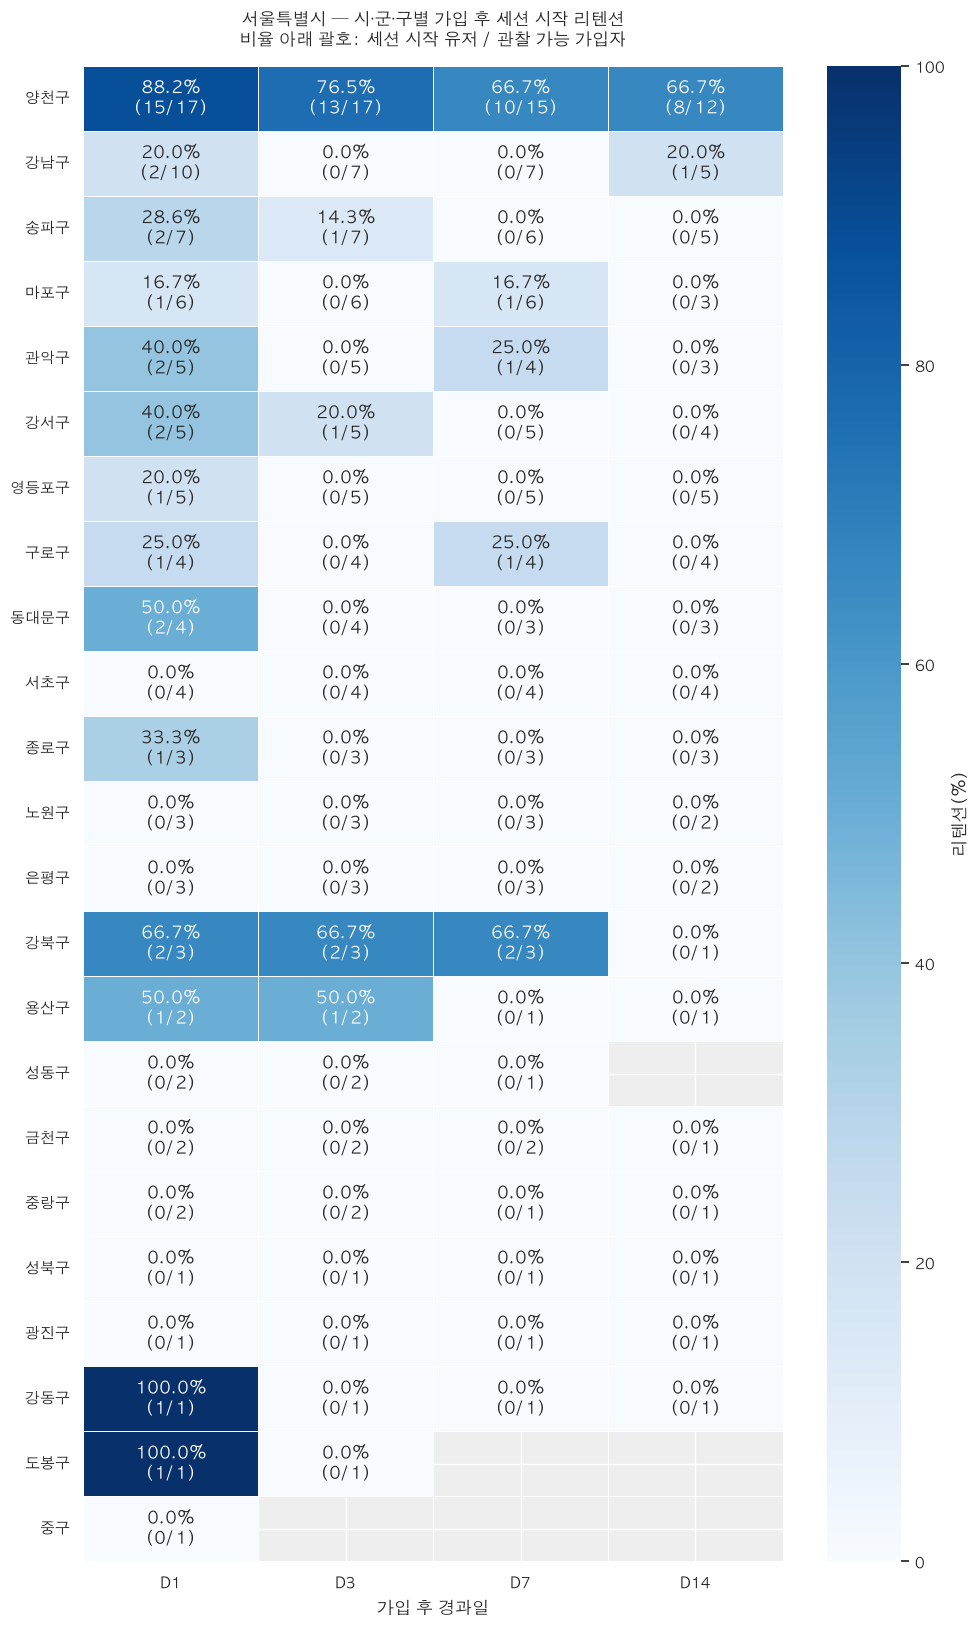

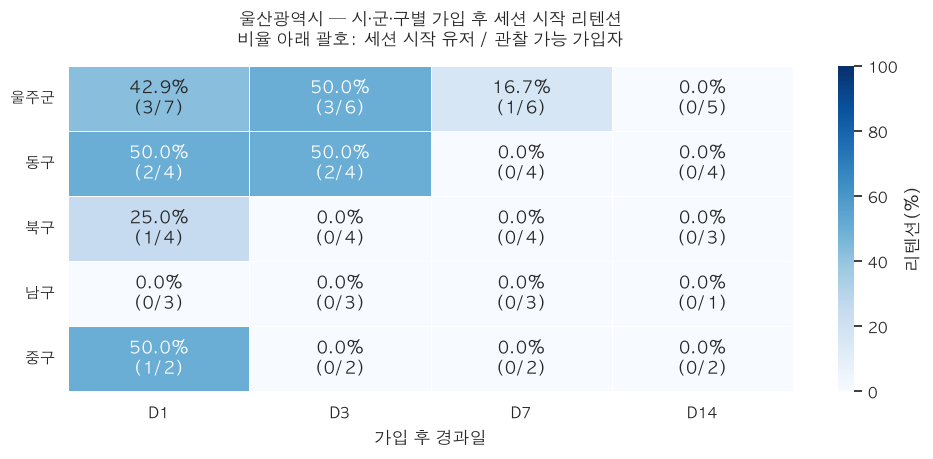

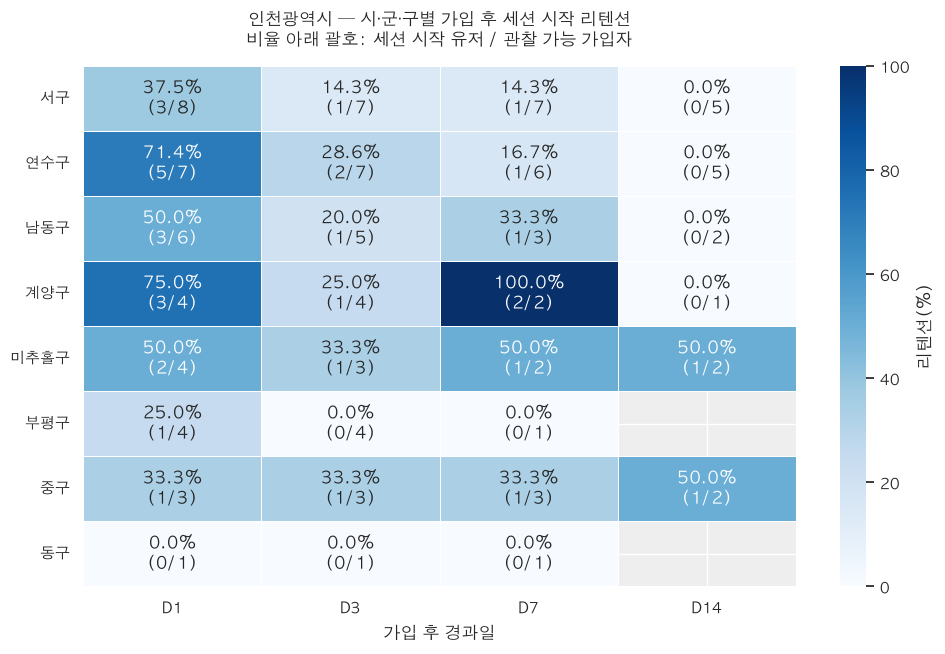

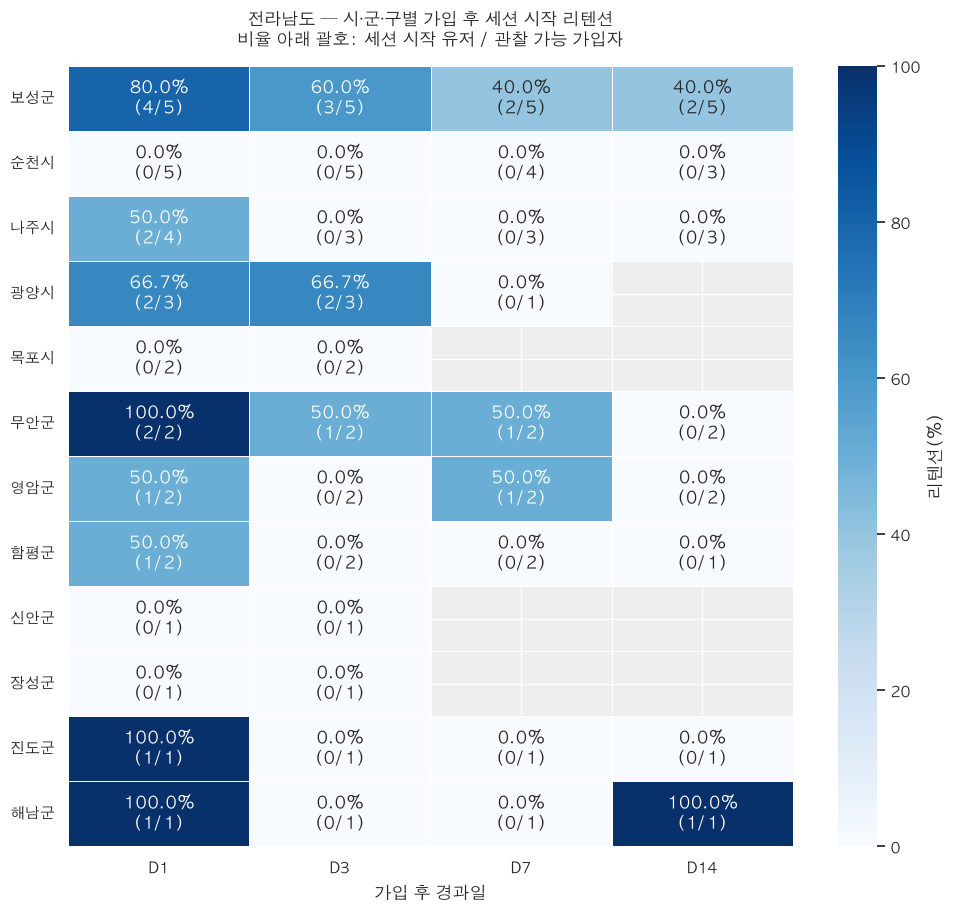

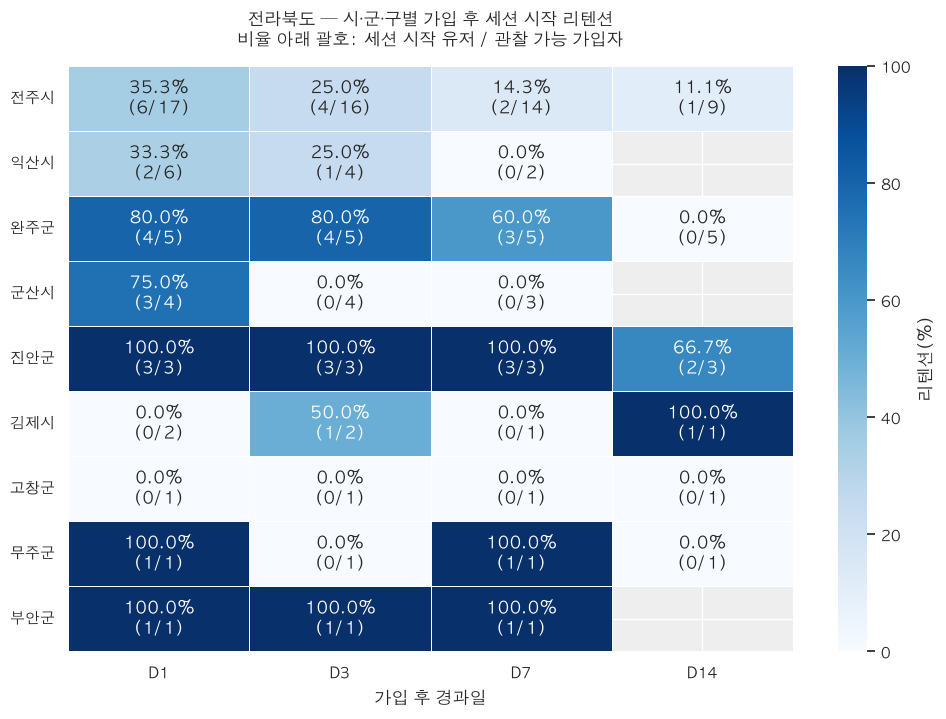

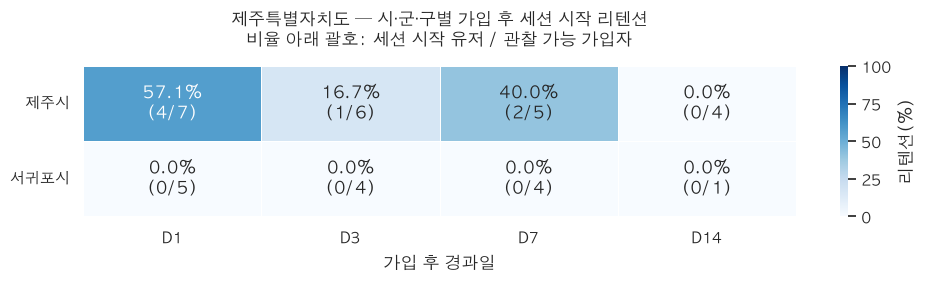

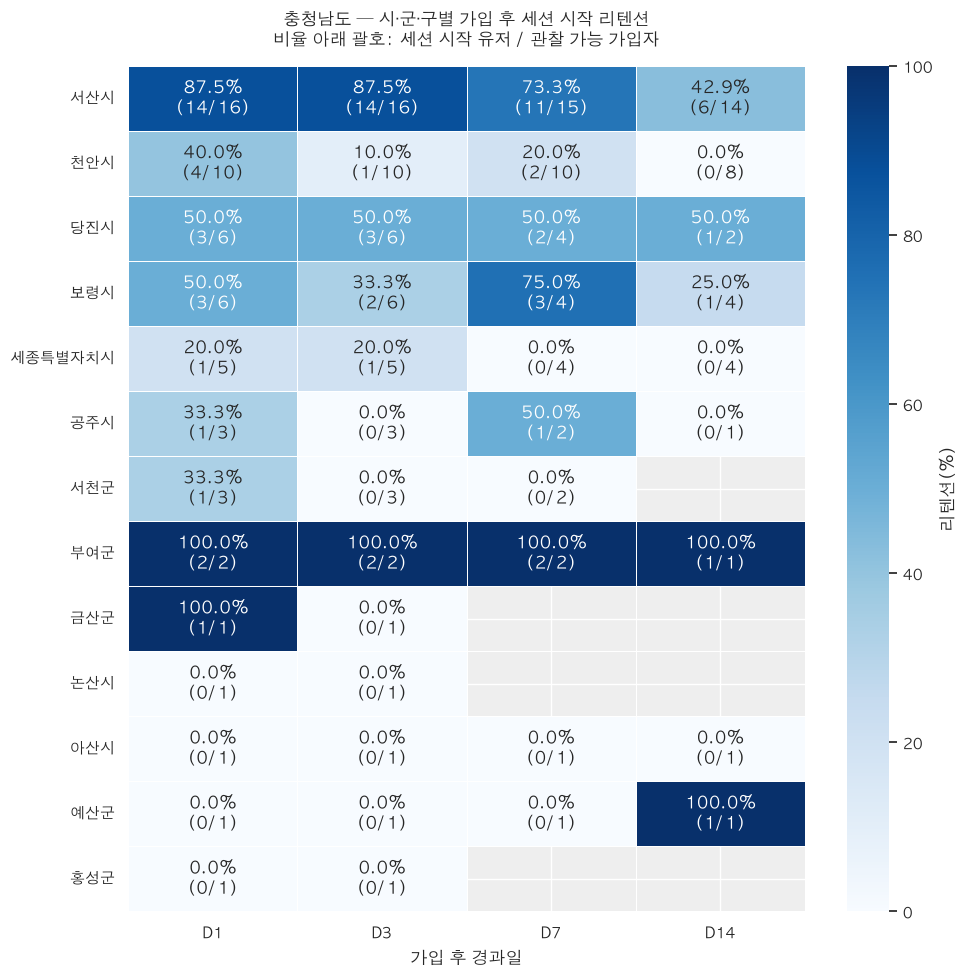

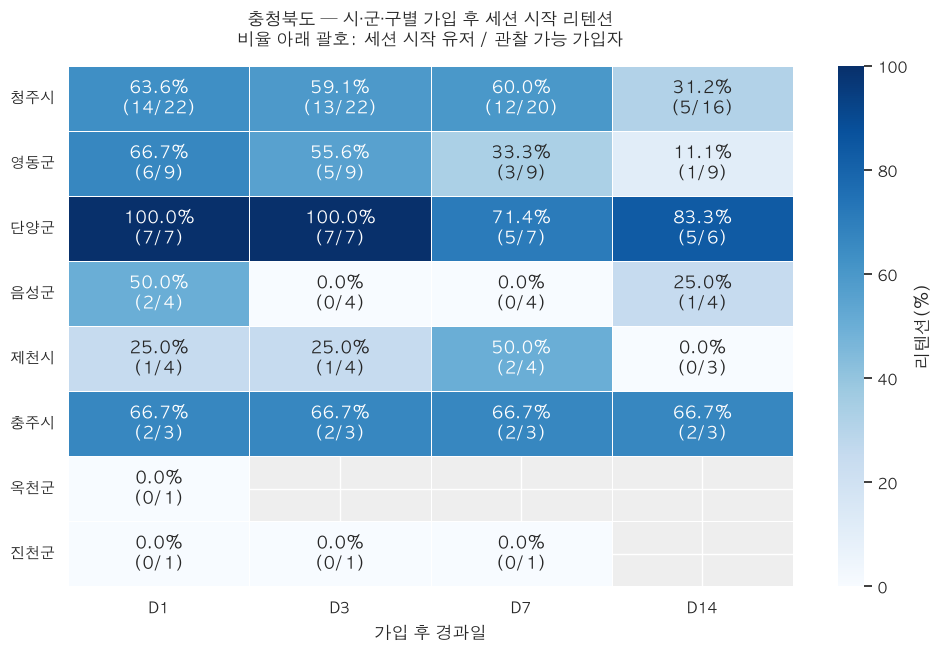

In [43]:
for sido, data in city_retention.groupby('시도', sort=True):
    plot_regional_retention(
        data,
        region_cols=['시군구'],
        title=f'{sido} — 시·군·구별 가입 후 세션 시작 리텐션',
    )

In [45]:
def retention_top3(data, region_cols, min_users=1):
    # 필요하면 최소 관찰 인원 기준 적용
    eligible = data.loc[
        data['관찰가능가입자수'].ge(min_users)
        & data['리텐션(%)'].notna()
    ].copy()

    # 표시용 반올림 이전 비율로 순위 계산
    eligible['_rate'] = (
        eligible['세션시작유저수']
        / eligible['관찰가능가입자수']
    )

    results = []

    for day in RETENTION_DAYS:
        top = (
            eligible.loc[eligible['경과일'].eq(f'D{day}')]
            .sort_values(
                ['_rate', '관찰가능가입자수'] + region_cols,
                ascending=[False, False] + [True] * len(region_cols),
            )
            .head(3)
            .copy()
        )

        top['순위'] = range(1, len(top) + 1)
        results.append(top)

    return pd.concat(results, ignore_index=True)[
        ['경과일', '순위'] + region_cols
        + ['관찰가능가입자수', '세션시작유저수', '리텐션(%)']
    ]

In [46]:
display(
    retention_top3(region_retention, region_cols=['시도'])
)

,경과일,순위,시도,관찰가능가입자수,세션시작유저수,리텐션(%)
0,D1,1,대전광역시,30,21,70.00
1,D1,2,충청북도,51,32,62.75
2,D1,3,충청남도,56,30,53.57
3,D3,1,충청북도,50,28,56.00
4,D3,2,대전광역시,28,14,50.00
5,D3,3,경상북도,70,33,47.14
6,D7,1,충청북도,48,24,50.00
7,D7,2,대전광역시,22,11,50.00
8,D7,3,충청남도,45,21,46.67
9,D14,1,광주광역시,8,3,37.50


In [47]:
display(
    retention_top3(city_retention, region_cols=['시도', '시군구'])
)

,경과일,순위,시도,시군구,관찰가능가입자수,세션시작유저수,리텐션(%)
0,D1,1,경상북도,청송군,11,11,100.0
1,D1,2,경기도,여주시,9,9,100.0
2,D1,3,충청북도,단양군,7,7,100.0
3,D3,1,경상북도,청송군,11,11,100.0
4,D3,2,경기도,여주시,9,9,100.0
5,D3,3,충청북도,단양군,7,7,100.0
6,D7,1,전라북도,진안군,3,3,100.0
7,D7,2,인천광역시,계양구,2,2,100.0
8,D7,3,충청남도,부여군,2,2,100.0
9,D14,1,경기도,하남시,1,1,100.0


In [48]:
display(
    retention_top3(
        city_retention,
        region_cols=['시도', '시군구'],
        min_users=10,
    )
)

,경과일,순위,시도,시군구,관찰가능가입자수,세션시작유저수,리텐션(%)
0,D1,1,경상북도,청송군,11,11,100.00
1,D1,2,서울특별시,양천구,17,15,88.24
2,D1,3,충청남도,서산시,16,14,87.50
3,D3,1,경상북도,청송군,11,11,100.00
4,D3,2,충청남도,서산시,16,14,87.50
5,D3,3,서울특별시,양천구,17,13,76.47
6,D7,1,경상북도,청송군,11,9,81.82
7,D7,2,충청남도,서산시,15,11,73.33
8,D7,3,서울특별시,양천구,15,10,66.67
9,D14,1,서울특별시,양천구,12,8,66.67
